   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.2 MB/s eta 0:00:00
Mounted at /content/drive
Unzipping: /content/drive/MyDrive/controlled MRI scan_dataset (1).zip -> /content/data_zip1
Unzipping: /content/drive/MyDrive/new Mri (1) (3).zip -> /content/data_zip2
Found 1938 DICOM files under /content/data_zip1
Found 2681 DICOM files under /content/data_zip2
Unique Image IDs found: 121
CSV rows total: 172
  Subject Image Data ID Group  label
0  110219     I10253274    PD      1
1  105711     I10253253    PD      1
2  101799     I10253235    PD      1
3  101748      I1495912    PD      1
4  101748      I1495907    PD      1

Label counts before filtering:
 label
1    100
0     72
Name: count, dtype: int64
Rows kept after DICOM matching: 121
Label counts after filtering:
 label
1    89
0    32
Name: count, dtype: int64
Unique subjects: 105


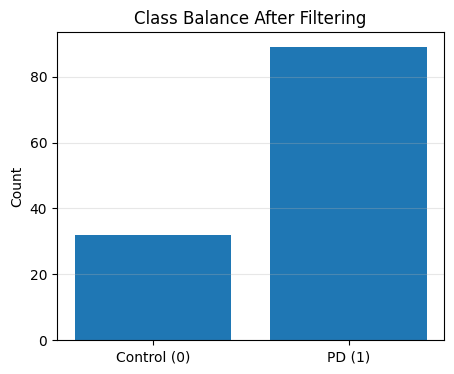

label
0    32
1    89
Name: count, dtype: int64


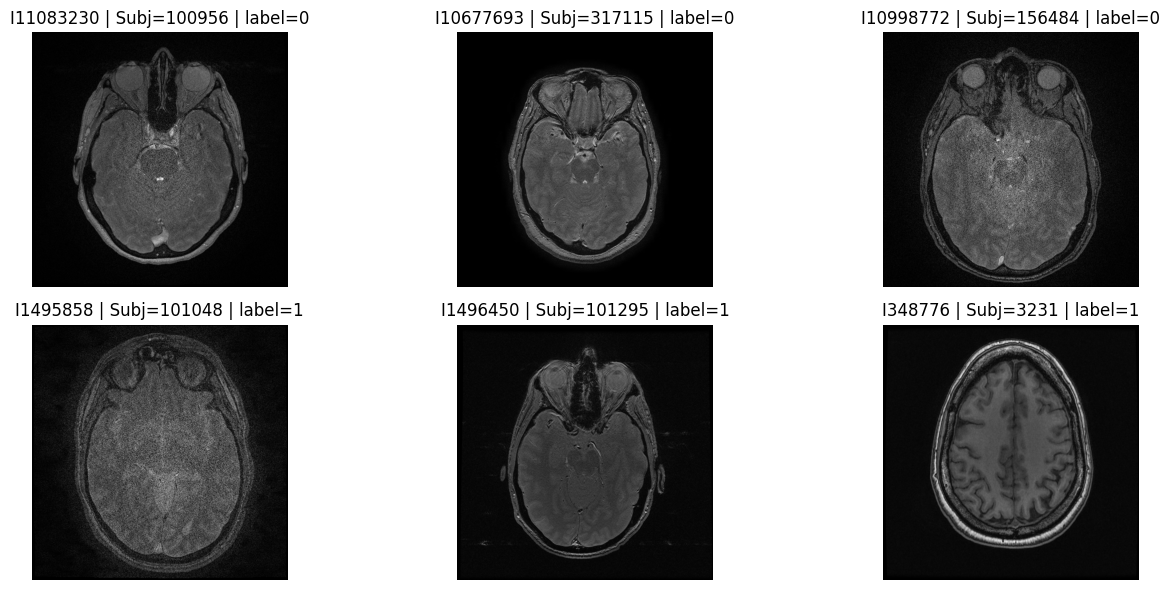


Fold 1
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Epoch 1/3, Loss: 0.6842
Epoch 2/3, Loss: 0.4353
Epoch 3/3, Loss: 0.3135
Fold 1 accuracy: 0.7600

Fold 2
Epoch 1/3, Loss: 0.7065
Epoch 2/3, Loss: 0.3395
Epoch 3/3, Loss: 0.3347
Fold 2 accuracy: 0.8333

Fold 3
Epoch 1/3, Loss: 0.6882
Epoch 2/3, Loss: 0.5070
Epoch 3/3, Loss: 0.2644
Fold 3 accuracy: 0.6667

Fold 4
Epoch 1/3, Loss: 0.6403
Epoch 2/3, Loss: 0.4209
Epoch 3/3, Loss: 0.3744
Fold 4 accuracy: 0.7083

Fold 5
Epoch 1/3, Loss: 0.6573
Epoch 2/3, Loss: 0.4203
Epoch 3/3, Loss: 0.2491
Fold 5 accuracy: 0.9167

Fold accuracies: [0.76, 0.8333333333333334, 0.6666666666666666, 0.7083333333333334, 0.9166666666666666]
Average validation accuracy: 0.7769999999999999


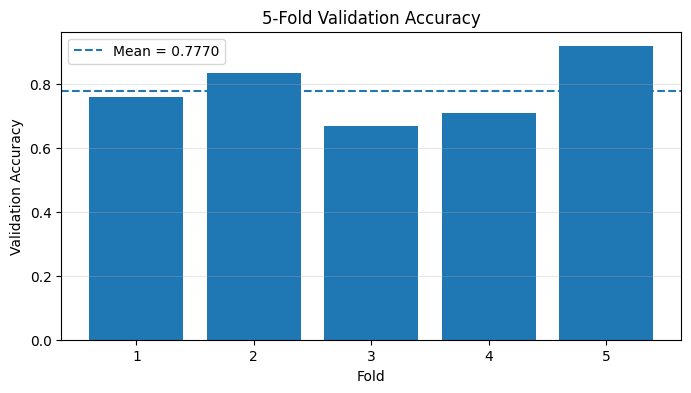

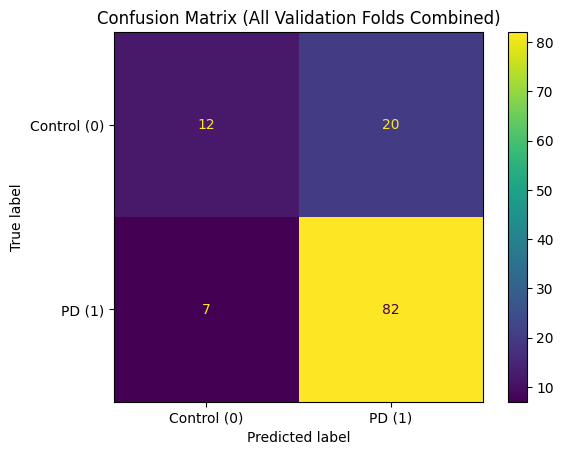

Final Output
Binary classification: Control vs PD
Average Accuracy: 0.7770
Confusion Matrix:
 [[12 20]
 [ 7 82]]


In [ ]:

!pip -q install pydicom torch torchvision scikit-learn matplotlib pandas pillow opencv-python

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pydicom

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# FILE PATHS
# =========================================================
PD_CSV_PATH   = "/content/drive/MyDrive/new_Mri_2_22_2026.csv"
CTRL_CSV_PATH = "/content/drive/MyDrive/controlled_MRI_scan_2_22_2026.csv"

ZIP_1_PATH = "/content/drive/MyDrive/controlled MRI scan_dataset.zip"
ZIP_2_PATH = "/content/drive/MyDrive/new Mri (1).zip"

EXTRACT_1_DIR = "/content/data_zip1"
EXTRACT_2_DIR = "/content/data_zip2"

os.makedirs(EXTRACT_1_DIR, exist_ok=True)
os.makedirs(EXTRACT_2_DIR, exist_ok=True)

# =========================================================
# UNZIP DATA
# =========================================================
def unzip_to(zip_path, out_dir):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"ZIP not found: {zip_path}")
    if len(os.listdir(out_dir)) > 0:
        print(f"[SKIP] Already extracted: {out_dir}")
        return
    print(f"Unzipping: {zip_path} -> {out_dir}")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

unzip_to(ZIP_1_PATH, EXTRACT_1_DIR)
unzip_to(ZIP_2_PATH, EXTRACT_2_DIR)

# =========================================================
# BUILD DICOM INDEX
# =========================================================
def build_dicom_index(base_dirs):
    idx = {}
    pat = re.compile(r"(I\d+)")

    for base in base_dirs:
        dcm_paths = glob.glob(os.path.join(base, "**", "*.dcm"), recursive=True)
        print(f"Found {len(dcm_paths)} DICOM files under {base}")

        for p in dcm_paths:
            m = pat.search(p)
            if m:
                img_id = m.group(1)
                idx.setdefault(img_id, []).append(p)

    for k in idx:
        idx[k] = sorted(idx[k])
    return idx

dicom_index = build_dicom_index([EXTRACT_1_DIR, EXTRACT_2_DIR])
print("Unique Image IDs found:", len(dicom_index))

if len(dicom_index) == 0:
    raise RuntimeError("No DICOM IDs found. Check zip contents and folder structure.")

# =========================================================
# LOAD CSV FILES
# =========================================================
if not os.path.exists(PD_CSV_PATH):
    raise FileNotFoundError(f"PD CSV not found: {PD_CSV_PATH}")
if not os.path.exists(CTRL_CSV_PATH):
    raise FileNotFoundError(f"Control CSV not found: {CTRL_CSV_PATH}")

df_pd = pd.read_csv(PD_CSV_PATH)
df_ctrl = pd.read_csv(CTRL_CSV_PATH)
df = pd.concat([df_pd, df_ctrl], ignore_index=True)

# Standardize columns
df["Image Data ID"] = df["Image Data ID"].astype(str)
df["Subject"] = df["Subject"].astype(str)
df["Group"] = df["Group"].astype(str)

# Binary classification label: Control=0, PD=1
df["label"] = df["Group"].str.lower().apply(lambda g: 1 if "pd" in g else 0)

print("CSV rows total:", len(df))
print(df[["Subject", "Image Data ID", "Group", "label"]].head())
print("\nLabel counts before filtering:\n", df["label"].value_counts())

# =========================================================
# KEEP ONLY ROWS WITH MATCHING DICOM
# =========================================================
df = df[df["Image Data ID"].isin(dicom_index.keys())].copy()

print("Rows kept after DICOM matching:", len(df))
print("Label counts after filtering:\n", df["label"].value_counts())
print("Unique subjects:", df["Subject"].nunique())

if df["label"].nunique() < 2:
    raise RuntimeError("Filtered data contains only one class. Both classes must be present.")

# =========================================================
# DICOM TO IMAGE
# =========================================================
def dicom_to_pil(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    img = np.asarray(ds.pixel_array)
    img = np.squeeze(img)

    if img.ndim == 3:
        if img.shape[-1] not in (3, 4):
            img = img[img.shape[0] // 2]

    while img.ndim > 3:
        img = np.squeeze(img[img.shape[0] // 2])

    if img.ndim == 1:
        L = img.shape[0]
        s = int(np.sqrt(L))
        img = img.reshape(s, s) if s * s == L else img.reshape(1, L)

    if img.ndim == 2:
        img = img.astype(np.float32)
        img = img - img.min()
        if img.max() > 0:
            img = img / img.max()
        img = (img * 255.0).clip(0, 255).astype(np.uint8)
        return Image.fromarray(img).convert("RGB")

    if img.ndim == 3 and img.shape[-1] in (3, 4):
        if img.shape[-1] == 4:
            img = img[..., :3]
        img = img.astype(np.uint8) if img.dtype != np.uint8 else img
        return Image.fromarray(img).convert("RGB")

    raise ValueError(f"Unsupported DICOM shape: {img.shape}")

def get_middle_slice(img_id):
    paths = dicom_index[img_id]
    return paths[len(paths) // 2]

# =========================================================
# DATASET CLASS
# =========================================================
class MRIDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row["Image Data ID"]
        y = int(row["label"])

        dcm_path = get_middle_slice(img_id)
        x = dicom_to_pil(dcm_path)
        x = self.transform(x)

        return x, torch.tensor(y, dtype=torch.long)

# =========================================================
# TRANSFORMS
# =========================================================
train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# =========================================================
# MODEL
# =========================================================
def make_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

# =========================================================
# CLASS BALANCE PLOT
# =========================================================
counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(["Control (0)", "PD (1)"], counts.values)
plt.ylabel("Count")
plt.title("Class Balance After Filtering")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

print(counts)

# =========================================================
# SAMPLE IMAGES
# =========================================================
def show_samples(dataframe, n_per_class=3):
    df0 = dataframe[dataframe["label"] == 0]
    df1 = dataframe[dataframe["label"] == 1]

    n0 = min(n_per_class, len(df0))
    n1 = min(n_per_class, len(df1))

    sample_df = pd.concat([
        df0.sample(n0, random_state=42),
        df1.sample(n1, random_state=42)
    ]).reset_index(drop=True)

    plt.figure(figsize=(14, 6))
    cols = 3
    rows = int(np.ceil(len(sample_df) / cols))

    for i in range(len(sample_df)):
        row = sample_df.iloc[i]
        pil_img = dicom_to_pil(get_middle_slice(row["Image Data ID"]))
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(pil_img)
        ax.set_title(f'{row["Image Data ID"]} | Subj={row["Subject"]} | label={row["label"]}')
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(df, n_per_class=3)

# =========================================================
# TRAIN + VALIDATE ONE FOLD
# =========================================================
def run_fold(train_df, val_df, epochs=3, batch_size=8, lr=1e-4, return_preds=False):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = make_model().to(device)

    train_loader = DataLoader(
        MRIDataset(train_df, train_tf),
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    val_loader = DataLoader(
        MRIDataset(val_df, val_tf),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    counts = train_df["label"].value_counts()
    n0, n1 = counts.get(0, 0), counts.get(1, 0)
    w0 = (n0 + n1) / (2.0 * n0)
    w1 = (n0 + n1) / (2.0 * n1)
    class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

    model.eval()
    ys, ps = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            pred = model(x).argmax(1).cpu().numpy()
            ps.extend(pred)
            ys.extend(y.numpy())

    acc = accuracy_score(ys, ps)

    if return_preds:
        return acc, np.array(ys), np.array(ps)
    return acc

# =========================================================
# 5-FOLD GROUP K-FOLD CROSS VALIDATION
# =========================================================
gkf = GroupKFold(n_splits=5)

accs = []
all_y_true = []
all_y_pred = []

for fold, (tr, va) in enumerate(gkf.split(df, df["label"], groups=df["Subject"]), start=1):
    print(f"\nFold {fold}")

    train_df = df.iloc[tr]
    val_df = df.iloc[va]

    acc, y_true, y_pred = run_fold(
        train_df,
        val_df,
        epochs=3,
        batch_size=8,
        lr=1e-4,
        return_preds=True
    )

    accs.append(acc)
    all_y_true.extend(y_true.tolist())
    all_y_pred.extend(y_pred.tolist())

    print(f"Fold {fold} accuracy: {acc:.4f}")

print("\nFold accuracies:", accs)
print("Average validation accuracy:", float(np.mean(accs)))

# =========================================================
# ACCURACY BAR CHART
# =========================================================
plt.figure(figsize=(8, 4))
x = np.arange(1, len(accs) + 1)
plt.bar(x, accs)
plt.axhline(np.mean(accs), linestyle="--", label=f"Mean = {np.mean(accs):.4f}")
plt.xticks(x)
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.title("5-Fold Validation Accuracy")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "PD (1)"]
)
disp.plot(values_format="d")
plt.title("Confusion Matrix (All Validation Folds Combined)")
plt.grid(False)
plt.show()

# =========================================================
# FINAL OUTPUT
# =========================================================
print("Final Output")
print("Binary classification: Control vs PD")
print(f"Average Accuracy: {np.mean(accs):.4f}")
print("Confusion Matrix:\n", cm)